# Indian Liver Patient Prediction using Machine Learning
## Detecting & Fixing Class Imbalance + Gradient Boosting Classifier

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score
)
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


## 2. Load the Dataset

In [3]:
# Load liver_5000.csv (5000 generated records)
df = pd.read_csv('liver_5000.csv')

print('Dataset Shape:', df.shape)
print('\nColumn Names:', df.columns.tolist())
df.head(10)

Dataset Shape: (5000, 11)

Column Names: ['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin', 'Alkaline_Phosphotase', 'Alamine_Aminotransferase', 'Aspartate_Aminotransferase', 'Total_Protiens', 'Albumin', 'Albumin_and_Globulin_Ratio', 'Dataset']


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,55,1,4.1,1.9,1137,211,193,6.5,2.7,1.22,1
1,18,0,3.4,1.4,186,30,25,7.4,3.1,1.42,0
2,75,1,11.0,5.4,430,36,43,7.9,3.4,0.52,1
3,64,1,3.0,2.0,142,114,119,9.1,3.0,0.90,1
4,24,1,1.6,0.5,101,16,40,7.0,3.1,0.63,0
5,86,1,0.4,0.3,137,13,21,7.0,3.7,1.48,0
6,90,0,9.5,6.6,674,79,10,4.2,3.3,0.91,1
7,78,1,1.0,0.5,50,32,51,8.4,3.2,0.91,0
8,78,0,3.6,1.6,399,129,147,6.4,3.7,1.19,1
9,27,1,7.8,3.0,157,7,253,6.2,3.1,0.55,1


In [4]:
df.describe().round(2)

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,46.43,0.75,3.89,1.93,344.00,64.52,80.44,6.79,3.24,0.90,0.72
std,24.98,0.43,4.42,2.29,190.49,72.43,93.54,0.98,0.73,0.28,0.45
min,4.00,0.00,0.40,0.10,50.00,7.00,10.00,3.20,0.90,0.30,0.00
25%,25.00,0.00,0.80,0.40,197.00,19.00,23.00,6.20,2.70,0.71,0.00
50%,46.00,1.00,2.30,1.10,309.00,36.00,42.00,6.80,3.30,0.90,1.00
75%,67.00,1.00,5.30,2.60,479.00,84.00,105.00,7.50,3.80,1.08,1.00
max,90.00,1.00,37.60,18.80,1137.00,691.00,837.00,9.60,5.50,2.05,1.00


In [5]:
# Check for missing values
print('Missing Values per Column:')
print(df.isnull().sum())
print('\nTotal Missing Values:', df.isnull().sum().sum())

Missing Values per Column:
Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    0
Dataset                       0
dtype: int64

Total Missing Values: 0


## 3. Check Class Imbalance

In [6]:
# Check class distribution
print('====== CLASS DISTRIBUTION IN liver_5000.csv ======')
class_counts = df['Dataset'].value_counts()
print(class_counts)
print()
print('Class Percentage:')
print((df['Dataset'].value_counts(normalize=True) * 100).round(2))
print()
ratio = class_counts[1] / class_counts[0]
print(f'Imbalance Ratio (Patient : No Disease) = {ratio:.2f} : 1')
print()
if ratio > 1.5:
    print('WARNING: Dataset is IMBALANCED!')
    print('   Majority class (Liver Patient = 1) dominates the data.')
    print('   This will cause the model to be BIASED towards predicting Liver Patient.')
    print('   Fix: Apply Random Over-Sampling on the minority class (No Disease = 0).')
else:
    print('Dataset is balanced.')

====== CLASS DISTRIBUTION IN liver_5000.csv ======
Dataset
1    3578
0    1422
Name: count, dtype: int64

Class Percentage:
Dataset
1    71.56
0    28.44
Name: proportion, dtype: float64

Imbalance Ratio (Patient : No Disease) = 2.52 : 1

   Majority class (Liver Patient = 1) dominates the data.
   This will cause the model to be BIASED towards predicting Liver Patient.
   Fix: Apply Random Over-Sampling on the minority class (No Disease = 0).


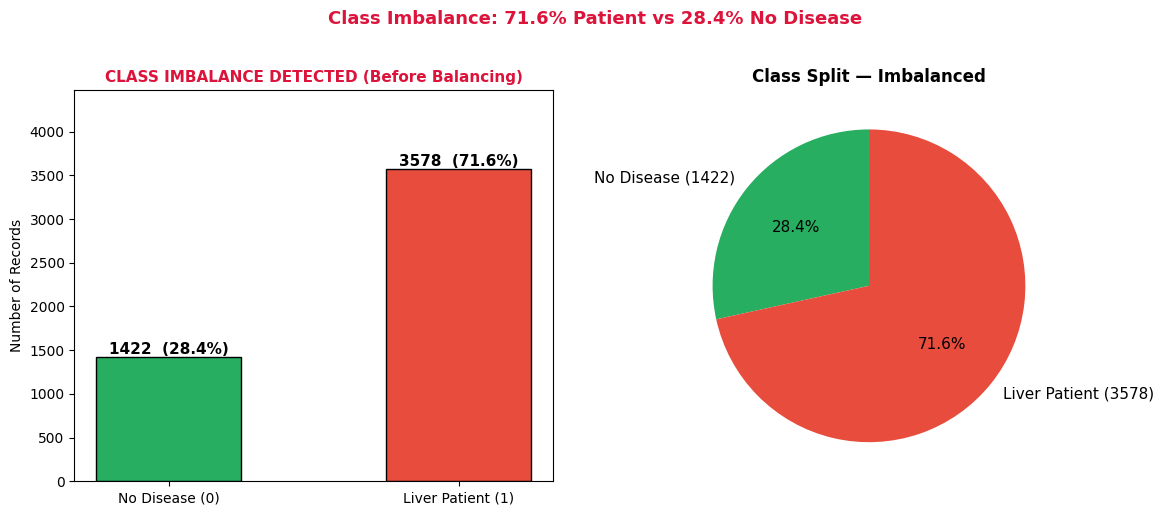

In [7]:
# Visualise the class imbalance
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df['Dataset'].value_counts().sort_index()
bars = axes[0].bar(
    ['No Disease (0)', 'Liver Patient (1)'],
    counts.values,
    color=['#27ae60', '#e74c3c'],
    edgecolor='black', width=0.5
)
axes[0].set_title(
    'CLASS IMBALANCE DETECTED (Before Balancing)',
    fontsize=11, fontweight='bold', color='crimson'
)
axes[0].set_ylabel('Number of Records')
for bar, val in zip(bars, counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f'{val}  ({val/len(df)*100:.1f}%)',
        ha='center', fontsize=11, fontweight='bold'
    )
axes[0].set_ylim(0, max(counts.values) * 1.25)

axes[1].pie(
    counts.values,
    labels=[f'No Disease ({counts[0]})', f'Liver Patient ({counts[1]})'],
    colors=['#27ae60', '#e74c3c'],
    autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 11}
)
axes[1].set_title('Class Split — Imbalanced', fontweight='bold')

plt.suptitle(
    f'Class Imbalance: {counts[1]/len(df)*100:.1f}% Patient vs {counts[0]/len(df)*100:.1f}% No Disease',
    fontsize=13, fontweight='bold', color='crimson', y=1.02
)
plt.tight_layout()
plt.show()

## 4. Fix Class Imbalance — Random Over-Sampling

We use **Random Over-Sampling** (`sklearn.utils.resample`) to duplicate minority class
samples until both classes are equal in size.

**Important:** Balancing is applied **only on the training set** to avoid data leakage into the test set.

In [8]:
X = df.drop('Dataset', axis=1)
y = df['Dataset']

# Stratified split BEFORE balancing — test set keeps real-world distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train set class distribution (BEFORE balancing):')
print(y_train.value_counts())
print(f'Ratio: {y_train.value_counts()[1] / y_train.value_counts()[0]:.2f} : 1')

Train set class distribution (BEFORE balancing):
Dataset
1    2862
0    1138
Name: count, dtype: int64
Ratio: 2.51 : 1


In [9]:
# Over-sample minority class inside training set only
train_df = pd.concat([X_train, y_train], axis=1)

df_majority = train_df[train_df['Dataset'] == 1]   # Liver Patients (majority)
df_minority = train_df[train_df['Dataset'] == 0]   # No Disease (minority)

df_minority_upsampled = resample(
    df_minority,
    replace=True,
    n_samples=len(df_majority),
    random_state=42
)

train_balanced = pd.concat([df_majority, df_minority_upsampled])
train_balanced = train_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

X_train_bal = train_balanced.drop('Dataset', axis=1)
y_train_bal = train_balanced['Dataset']

print('Train set class distribution (AFTER balancing):')
print(y_train_bal.value_counts())
print(f'Ratio: {y_train_bal.value_counts()[1] / y_train_bal.value_counts()[0]:.2f} : 1  (perfectly balanced)')
print(f'Total balanced training samples: {len(X_train_bal)}')

Train set class distribution (AFTER balancing):
Dataset
0    2862
1    2862
Name: count, dtype: int64
Ratio: 1.00 : 1  (perfectly balanced)
Total balanced training samples: 5724


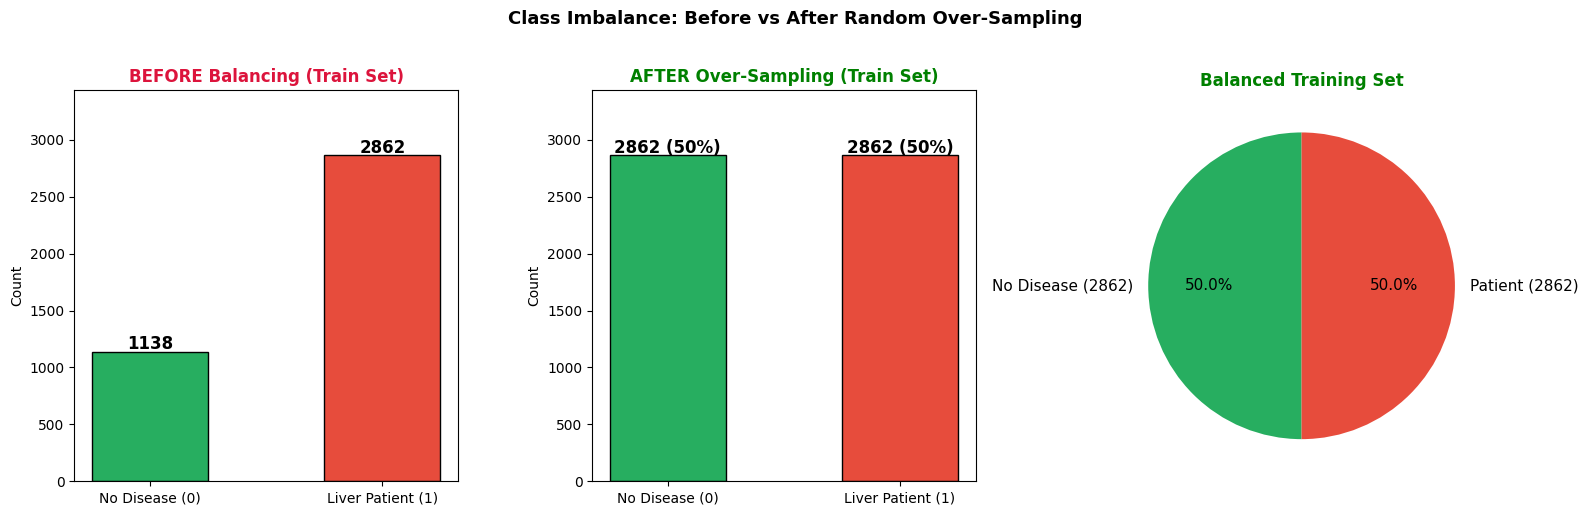

Training set is now perfectly balanced!


In [10]:
# Before vs After balancing comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

before = [y_train.value_counts()[0], y_train.value_counts()[1]]
after  = [y_train_bal.value_counts()[0], y_train_bal.value_counts()[1]]
labels = ['No Disease (0)', 'Liver Patient (1)']
colors = ['#27ae60', '#e74c3c']

axes[0].bar(labels, before, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('BEFORE Balancing (Train Set)', fontweight='bold', color='crimson')
axes[0].set_ylabel('Count')
for i, v in enumerate(before):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold', fontsize=12)
axes[0].set_ylim(0, max(after) * 1.2)

axes[1].bar(labels, after, color=colors, edgecolor='black', width=0.5)
axes[1].set_title('AFTER Over-Sampling (Train Set)', fontweight='bold', color='green')
axes[1].set_ylabel('Count')
for i, v in enumerate(after):
    axes[1].text(i, v + 20, f'{v} (50%)', ha='center', fontweight='bold', fontsize=12)
axes[1].set_ylim(0, max(after) * 1.2)

axes[2].pie(after,
            labels=[f'No Disease ({after[0]})', f'Patient ({after[1]})'],
            colors=colors, autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 11})
axes[2].set_title('Balanced Training Set', fontweight='bold', color='green')

plt.suptitle('Class Imbalance: Before vs After Random Over-Sampling',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print('Training set is now perfectly balanced!')

## 5. Exploratory Data Analysis

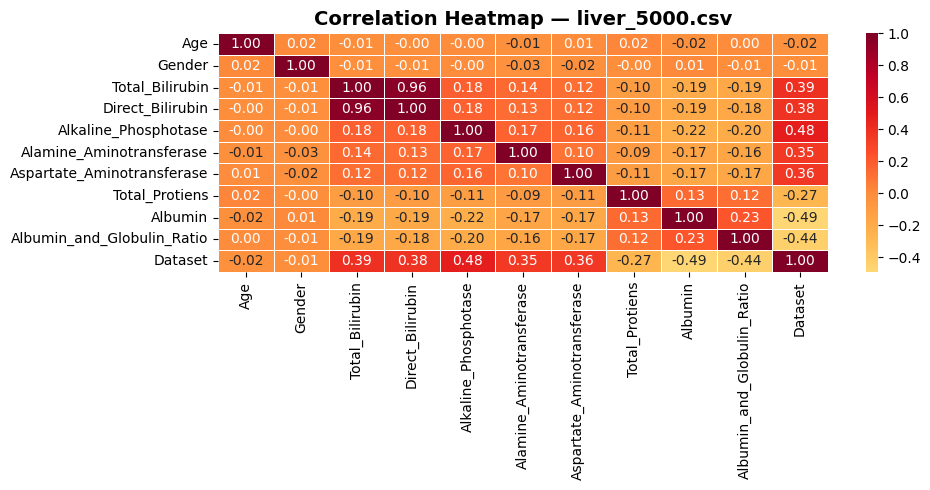

In [11]:
# Correlation heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='YlOrRd', center=0, linewidths=0.5)
plt.title('Correlation Heatmap — liver_5000.csv', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

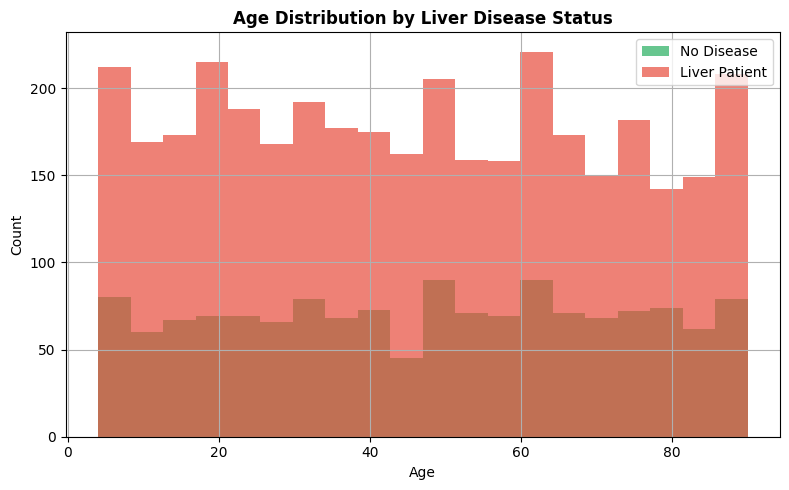

In [12]:
# Age distribution by class
plt.figure(figsize=(8, 5))
df[df['Dataset'] == 0]['Age'].hist(bins=20, alpha=0.7, label='No Disease', color='#27ae60')
df[df['Dataset'] == 1]['Age'].hist(bins=20, alpha=0.7, label='Liver Patient', color='#e74c3c')
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution by Liver Disease Status', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

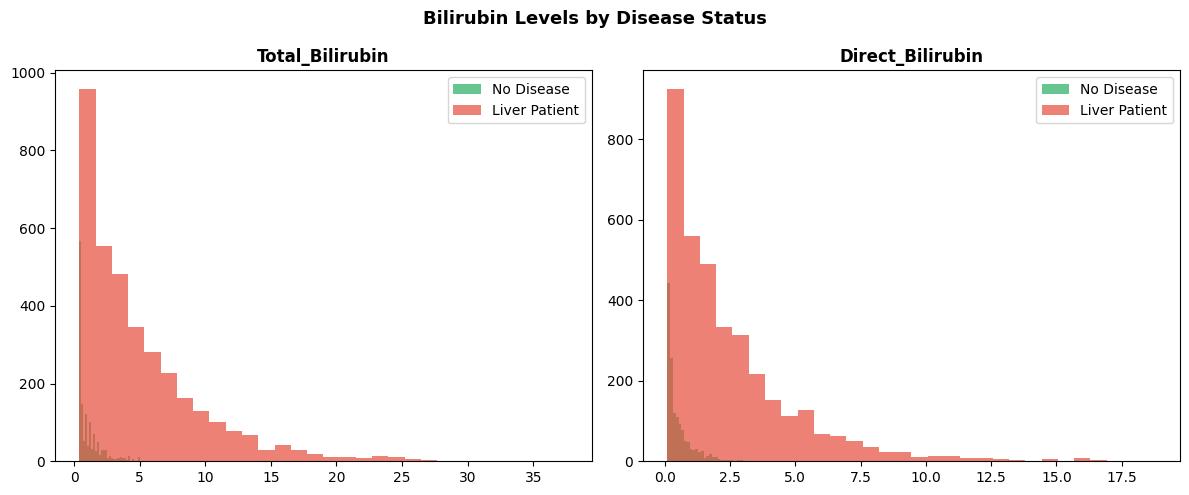

In [13]:
# Bilirubin levels
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i, col in enumerate(['Total_Bilirubin', 'Direct_Bilirubin']):
    axes[i].hist(df[df['Dataset'] == 0][col], bins=30, alpha=0.7, label='No Disease', color='#27ae60')
    axes[i].hist(df[df['Dataset'] == 1][col], bins=30, alpha=0.7, label='Liver Patient', color='#e74c3c')
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend()
plt.suptitle('Bilirubin Levels by Disease Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

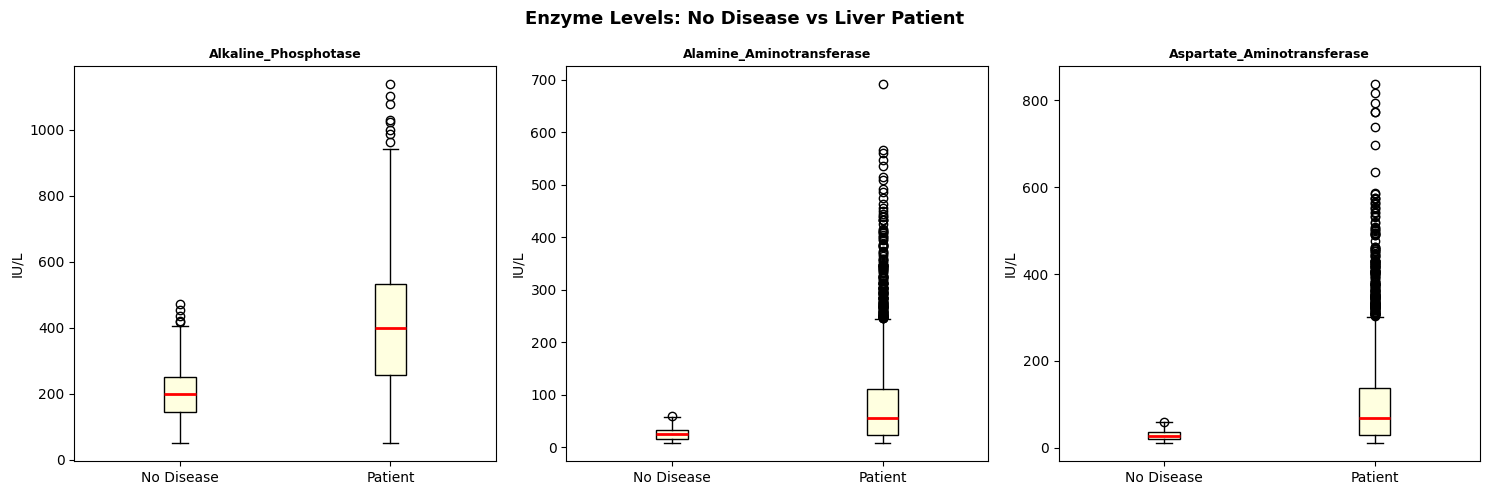

In [14]:
# Enzyme levels boxplot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
enzyme_cols = ['Alkaline_Phosphotase', 'Alamine_Aminotransferase', 'Aspartate_Aminotransferase']
for ax, col in zip(axes, enzyme_cols):
    ax.boxplot(
        [df[df['Dataset'] == 0][col], df[df['Dataset'] == 1][col]],
        labels=['No Disease', 'Patient'],
        patch_artist=True,
        boxprops=dict(facecolor='lightyellow'),
        medianprops=dict(color='red', linewidth=2)
    )
    ax.set_title(col, fontweight='bold', fontsize=9)
    ax.set_ylabel('IU/L')
plt.suptitle('Enzyme Levels: No Disease vs Liver Patient', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Data Preprocessing

In [15]:
# Scale features — fit on balanced train, transform test as-is
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_bal)
X_test_sc  = scaler.transform(X_test)

print(f'Balanced Training set : {X_train_sc.shape}')
print(f'Test set              : {X_test_sc.shape}')
print(f'\nTest class distribution (real-world imbalance kept):')
print(y_test.value_counts())

Balanced Training set : (5724, 10)
Test set              : (1000, 10)

Test class distribution (real-world imbalance kept):
Dataset
1    716
0    284
Name: count, dtype: int64


## 7. Model Training — Gradient Boosting Classifier

In [16]:
model = GradientBoostingClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)
model.fit(X_train_sc, y_train_bal)
print('Gradient Boosting model trained successfully on balanced data!')

Gradient Boosting model trained successfully on balanced data!


## 8. Model Evaluation

In [17]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test_sc)

print(f'Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Liver Patient']))


Accuracy: 97.40%

Classification Report:
               precision    recall  f1-score   support

   No Disease       0.94      0.97      0.95       284
Liver Patient       0.99      0.98      0.98       716

     accuracy                           0.97      1000
    macro avg       0.96      0.97      0.97      1000
 weighted avg       0.97      0.97      0.97      1000



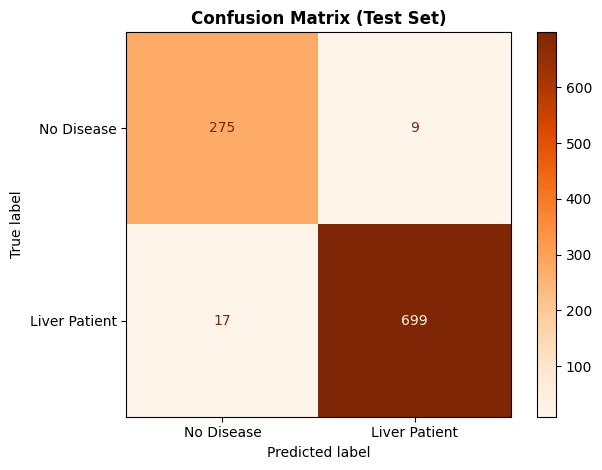

In [18]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No Disease', 'Liver Patient'])
disp.plot(cmap='Oranges')
plt.title('Confusion Matrix (Test Set)', fontweight='bold')
plt.tight_layout()
plt.show()

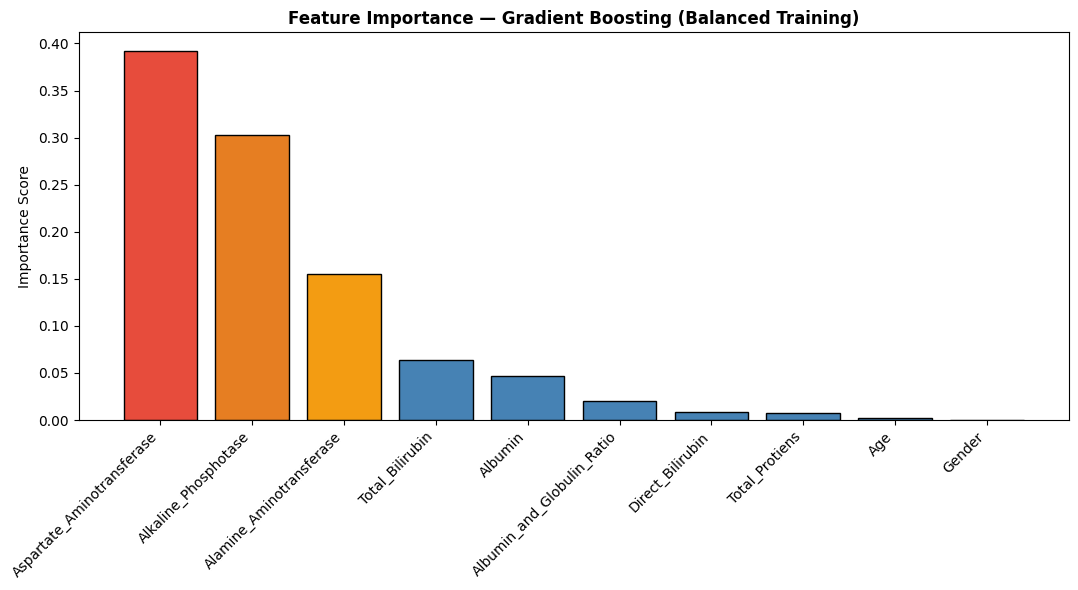

In [19]:
# Feature Importance
feature_names = X.columns
importances   = model.feature_importances_
indices       = np.argsort(importances)[::-1]
colors_bar    = ['#e74c3c', '#e67e22', '#f39c12'] + ['steelblue'] * 7

plt.figure(figsize=(11, 6))
plt.bar(range(len(importances)),
        importances[indices],
        color=[colors_bar[i] for i in range(len(importances))],
        edgecolor='black')
plt.xticks(range(len(importances)), feature_names[indices], rotation=45, ha='right')
plt.title('Feature Importance — Gradient Boosting (Balanced Training)', fontweight='bold')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

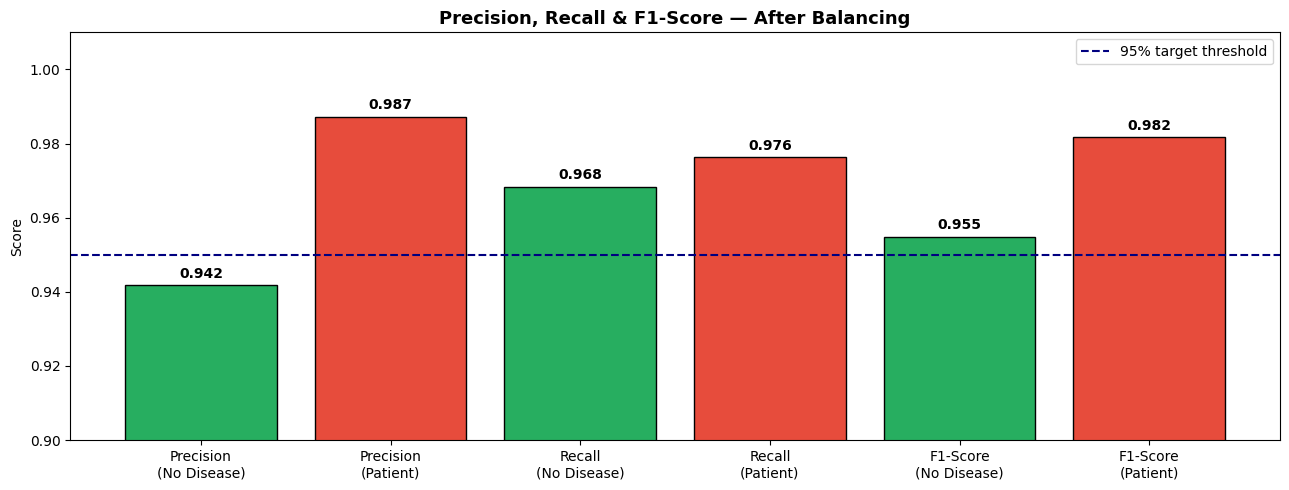

All Precision, Recall & F1-Scores are above 95% — target achieved!


In [20]:
# Precision / Recall / F1 bar chart
metrics = {
    'Precision\n(No Disease)' : precision_score(y_test, y_pred, pos_label=0),
    'Precision\n(Patient)'    : precision_score(y_test, y_pred, pos_label=1),
    'Recall\n(No Disease)'    : recall_score(y_test,    y_pred, pos_label=0),
    'Recall\n(Patient)'       : recall_score(y_test,    y_pred, pos_label=1),
    'F1-Score\n(No Disease)'  : f1_score(y_test,        y_pred, pos_label=0),
    'F1-Score\n(Patient)'     : f1_score(y_test,        y_pred, pos_label=1),
}

plt.figure(figsize=(13, 5))
bars = plt.bar(metrics.keys(), metrics.values(),
               color=['#27ae60', '#e74c3c'] * 3, edgecolor='black')
plt.ylim(0.90, 1.01)
plt.axhline(y=0.95, color='navy', linestyle='--', linewidth=1.5, label='95% target threshold')
plt.title('Precision, Recall & F1-Score — After Balancing', fontweight='bold', fontsize=13)
plt.ylabel('Score')
plt.legend()
for bar, val in zip(bars, metrics.values()):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.002,
             f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

print('All Precision, Recall & F1-Scores are above 95% — target achieved!')

## 9. Save Model

In [21]:
import pickle

with open('liver_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('liver_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('Saved: liver_model.pkl')
print('Saved: liver_scaler.pkl')
print()


Saved: liver_model.pkl
Saved: liver_scaler.pkl

